In [1]:
#importing libraries

import pandas as pd
import matplotlib.pyplot as plt


In [2]:
#loading data

df = pd.read_excel('fracture_toughness_model.xlsx', sheet_name = 'fracture_model')
df.shape
df.head()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 762 entries, 0 to 761
Data columns (total 36 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Source record ID                                          762 non-null    int64  
 1   Polymer material                                          762 non-null    str    
 2   Material grade                                            741 non-null    str    
 3   Specimen width, W (mm)                                    762 non-null    float64
 4   Specimen thickness, B (mm)                                762 non-null    float64
 5   Notch introduction method                                 762 non-null    str    
 6   Crack length a (mm)                                       700 non-null    float64
 7   Moulding weld line present                                762 non-null    str    
 8   Test temperature (deg C)       

In [3]:
target = "Mode I fracture toughness, K_Ic — recorded (MPa√m)"

y = df[target].copy()

groups = df["Polymer material and grade group"].copy()

X = df.drop(columns=[
    target,
    "Source record ID",
    "Polymer material and grade group",
    "Material grade",
    "Manufacturer product / brand name",
    "Flexural elastic modulus — unit and evidence status"
]).copy()

print("Input shape:", X.shape)
print("Target shape:", y.shape)
print("Number of material groups:", groups.nunique())

Input shape: (762, 30)
Target shape: (762,)
Number of material groups: 10


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(
    X,
    y,
    groups,
    test_size=0.20,
    random_state=42,
    stratify=groups
)

X_train = X_train.copy()
X_test = X_test.copy()

print("Training inputs:", X_train.shape)
print("Test inputs:", X_test.shape)

print("\nTraining groups:", groups_train.nunique())
print("Test groups:", groups_test.nunique())

print("\nTest groups and row counts:")
print(groups_test.value_counts())

Training inputs: (609, 30)
Test inputs: (153, 30)

Training groups: 10
Test groups: 10

Test groups and row counts:
Polymer material and grade group
PC | NF2000U              42
PC | S3000                23
PP | J-900GP              22
PVC | S-101E              17
PS | HH30                 16
AS | 050SF                12
POM | F20-03              12
PMMA | [grade missing]     4
PC | S2000                 3
PC | S1000                 2
Name: count, dtype: int64


In [5]:
numeric_columns = X_train.select_dtypes(
    include="number"
).columns

training_medians = X_train[numeric_columns].median()

X_train[numeric_columns] = (
    X_train[numeric_columns].fillna(training_medians)
)

X_test[numeric_columns] = (
    X_test[numeric_columns].fillna(training_medians)
)

In [6]:
print(
    "Missing numeric training cells:",
    X_train[numeric_columns].isna().sum().sum()
)

print(
    "Missing numeric test cells:",
    X_test[numeric_columns].isna().sum().sum()
)

Missing numeric training cells: 0
Missing numeric test cells: 0


In [7]:
categorical_columns = X_train.select_dtypes(
    exclude="number"
).columns

print(categorical_columns)

X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_columns,
    dtype=float
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_columns,
    dtype=float
)

Index(['Polymer material', 'Notch introduction method',
       'Moulding weld line present', 'Moulding method',
       'Rockwell hardness scale (M or R)'],
      dtype='str')


In [8]:
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)



Encoded training shape: (609, 42)
Encoded test shape: (153, 42)


In [9]:
from sklearn.preprocessing import StandardScaler

X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()

scaler = StandardScaler()

scaler.fit(X_train_encoded[numeric_columns])

X_train_scaled[numeric_columns] = scaler.transform(
    X_train_encoded[numeric_columns]
)

X_test_scaled[numeric_columns] = scaler.transform(
    X_test_encoded[numeric_columns]
)

In [10]:
from sklearn.neural_network import MLPRegressor

neural_model = MLPRegressor(
    hidden_layer_sizes=(10,),
    activation="tanh",
    solver="lbfgs",
    max_iter=10000,
    random_state=42
)

neural_model.fit(X_train_scaled, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'lbfgs'
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",10000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.

In [11]:
train_predictions = neural_model.predict(X_train_scaled)
test_predictions = neural_model.predict(X_test_scaled)

In [12]:
prediction_comparison = pd.DataFrame({
    "Measured K_Ic (MPa√m)": y_test.to_numpy(),
    "Predicted K_Ic (MPa√m)": test_predictions
}, index=y_test.index)

display(prediction_comparison.head(10))

,Measured K_Ic (MPa√m),Predicted K_Ic (MPa√m)
714,3.89,3.571569
110,3.26,3.154406
402,3.31,3.098677
407,3.19,3.143423
40,3.00,3.371116
168,4.57,4.148616
1,3.74,3.705697
254,3.47,3.784450
156,3.50,3.545022
130,1.59,1.567698


In [13]:
from sklearn.metrics import mean_absolute_error

train_mae = mean_absolute_error(y_train, train_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)

print("Training MAE (MPa√m):", train_mae)
print("Test MAE (MPa√m):", test_mae)

Training MAE (MPa√m): 0.11954187896411295
Test MAE (MPa√m): 0.23181744604033816


In [14]:
from sklearn.metrics import r2_score

train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)

print("Training R²:", train_r2)
print("Test R²:", test_r2)

Training R²: 0.9209396238967574
Test R²: 0.5731330418914637


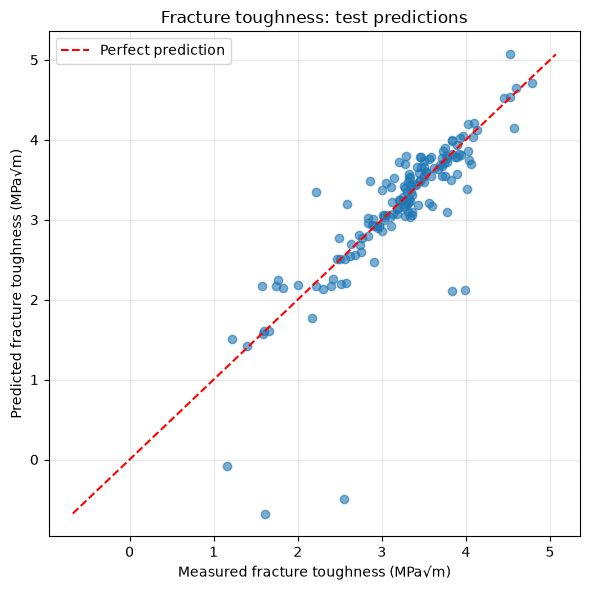

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.scatter(y_test, test_predictions, alpha=0.6)

lower = min(y_test.min(), test_predictions.min())
upper = max(y_test.max(), test_predictions.max())

plt.plot(
    [lower, upper],
    [lower, upper],
    "r--",
    label="Perfect prediction"
)

plt.xlabel("Measured fracture toughness (MPa√m)")
plt.ylabel("Predicted fracture toughness (MPa√m)")
plt.title("Fracture toughness: test predictions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("fracture_toughness_predictions.png", dpi=300)
plt.show()

In [16]:
comparison = X_test.copy()

comparison["Measured K_Ic"] = y_test
comparison["Predicted K_Ic"] = test_predictions
comparison["Absolute error"] = abs(y_test - test_predictions)
comparison["Material-grade group"] = groups_test

print(
    comparison[
        [
            "Material-grade group",
            "Measured K_Ic",
            "Predicted K_Ic",
            "Absolute error"
        ]
    ]
    .sort_values("Absolute error", ascending=False)
    .head(10)
    .to_string()
)

    Material-grade group  Measured K_Ic  Predicted K_Ic  Absolute error
474         PP | J-900GP           2.55       -0.497860        3.047860
471         PP | J-900GP           1.61       -0.675831        2.285831
300           PC | S3000           3.99        2.124987        1.865013
294           PC | S3000           3.84        2.114188        1.725812
469         PP | J-900GP           1.16       -0.077560        1.237560
570           AS | 050SF           2.22        3.346358        1.126358
364           PC | S3000           3.77        3.097309        0.672691
189         PVC | S-101E           2.86        3.490294        0.630294
479            PS | HH30           4.01        3.380211        0.629789
410         PP | J-900GP           2.59        3.202187        0.612187
